In [1]:
# Librería principal para manejo de datos tabulares (como Excel, pero en Python)
import pandas as pd
# Operaciones matemáticas de alto rendimiento sobre arrays y matrices
import numpy as np
# Motor de graficación: controla ejes, títulos, colores, tamaños
import matplotlib.pyplot as plt
# Gráficas estadísticas elegantes construidas sobre matplotlib
import seaborn as sns
# El clasificador de árbol de decisión y su visualizador gráfico
from sklearn.tree import DecisionTreeClassifier, plot_tree
# Función para partir el dataset en entrenamiento (80%) y prueba (20%)
from sklearn.model_selection import train_test_split
# Codificador One-Hot: convierte variables categóricas en columnas numéricas
from sklearn.preprocessing import OneHotEncoder
# Funciones para medir el desempeño del modelo
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("✅ Todas las librerías cargadas correctamente")

✅ Todas las librerías cargadas correctamente


In [2]:
# Carga el archivo CSV desde la ruta indicada; crea un DataFrame en memoria RAM
df = pd.read_csv('talentwell_data.csv')

# Muestra las primeras 5 filas para verificar que los datos se cargaron correctamente
print("=== Primeras 5 filas ===")
print(df.head())
print()

# shape devuelve una tupla (n_filas, n_columnas): nos dice el tamaño del dataset
print(f"Dimensiones del dataset: {df.shape[0]} registros × {df.shape[1]} columnas")

=== Primeras 5 filas ===
   horas_trabajo_dia   modalidad  horas_sueno  reuniones_dia  \
0                9.5      remoto          7.1              4   
1                8.2     hibrido          4.8              3   
2                9.8  presencial          6.9              2   
3               11.5      remoto          4.0              3   
4                8.0      remoto          7.3              4   

   anios_experiencia  actividad_fisica_semanal  score_agotamiento  \
0               13.6                         0               4.80   
1               11.6                         0               5.30   
2                1.6                         0               5.19   
3                3.4                         3               7.97   
4                9.6                         1               4.79   

   riesgo_burnout  
0               0  
1               0  
2               1  
3               1  
4               0  

Dimensiones del dataset: 1500 registros × 8 columnas


In [3]:
# El porcentaje de burnout nos dice si el dataset está desbalanceado
pct_burnout = df['riesgo_burnout'].mean() * 100
print(f"Porcentaje de empleados con riesgo de burnout: {pct_burnout:.1f}%")
print()
# Interpretación: con ~23% de positivos el dataset está moderadamente desbalanceado.
# Un modelo que siempre predice "0" acertaría el 77%... pero no detectaría ningún burnout.

Porcentaje de empleados con riesgo de burnout: 22.9%



In [ ]:
# Instancia el codificador One-Hot
# sparse_output=False → devuelve array NumPy normal (no matriz dispersa)
# drop='first' → elimina la primera categoría para evitar redundancia
ohe = OneHotEncoder(
    sparse_output=False, 
    drop='first')

# fit_transform hace DOS cosas a la vez:
# 1. fit: aprende qué categorías existen en la columna ('hibrido', 'presencial', 'remoto')
# 2. transform: convierte esas categorías en columnas binarias (0s y 1s)
# Recibe un DataFrame de UNA columna (doble corchete) → devuelve array 2D
modalidad_encoded = ohe.fit_transform(df[['modalidad']])

# get_feature_names_out genera los nombres de las nuevas columnas automáticamente
# Resultado esperado: ['modalidad_presencial', 'modalidad_remoto']  (hibrido fue eliminado)
nombres_columnas = ohe.get_feature_names_out(['modalidad']).tolist()

print(f"Categorías aprendidas por el OHE: {ohe.categories_}")
print(f"Columnas generadas (drop='first' eliminó la primera): {nombres_columnas}")
print(f"Forma del array codificado: {modalidad_encoded.shape}  → (filas, nuevas_columnas)")

Categorías aprendidas por el OHE: [array(['hibrido', 'presencial', 'remoto'], dtype=object)]
Columnas generadas (drop='first' eliminó la primera): ['modalidad_presencial', 'modalidad_remoto']
Forma del array codificado: (1500, 2)  → (filas, nuevas_columnas)


In [6]:
# Agrega las nuevas columnas binarias al DataFrame original
# modalidad_encoded[:, i] extrae la columna i del array NumPy
for i, col in enumerate(nombres_columnas):
    df[col] = modalidad_encoded[:, i]  # añade la columna al df

# Verifica el resultado: las columnas nuevas deben aparecer al final
print("=== Columnas del DataFrame después del OHE ===")
print(df.columns.tolist())
print()

# Comprueba que los valores son correctos
print("=== Ejemplo: modalidad original vs columnas OHE (5 filas) ===")
print(df[['modalidad', 'modalidad_presencial', 'modalidad_remoto']].head(10))
print()
print("Regla de lectura:")
print("  presencial=0, remoto=0 → hibrido (categoría base eliminada por drop='first')")
print("  presencial=1, remoto=0 → presencial")
print("  presencial=0, remoto=1 → remoto")

=== Columnas del DataFrame después del OHE ===
['horas_trabajo_dia', 'modalidad', 'horas_sueno', 'reuniones_dia', 'anios_experiencia', 'actividad_fisica_semanal', 'score_agotamiento', 'riesgo_burnout', 'modalidad_presencial', 'modalidad_remoto']

=== Ejemplo: modalidad original vs columnas OHE (5 filas) ===
    modalidad  modalidad_presencial  modalidad_remoto
0      remoto                   0.0               1.0
1     hibrido                   0.0               0.0
2  presencial                   1.0               0.0
3      remoto                   0.0               1.0
4      remoto                   0.0               1.0
5      remoto                   0.0               1.0
6     hibrido                   0.0               0.0
7  presencial                   1.0               0.0
8     hibrido                   0.0               0.0
9  presencial                   1.0               0.0

Regla de lectura:
  presencial=0, remoto=0 → hibrido (categoría base eliminada por drop='first')

In [7]:
# Lista de features (variables de entrada) que usará el modelo
# Nota: excluimos 'score_agotamiento' y 'modalidad' (ya fue codificada en columnas binarias)
features = [
    'horas_trabajo_dia',       # cuánto trabaja al día
    'horas_sueno',             # cuánto duerme
    'reuniones_dia',           # carga de reuniones
    'actividad_fisica_semanal',# factor protector
    'anios_experiencia',       # puede indicar resiliencia o desgaste
    'modalidad_presencial',    # OHE: ¿trabaja presencial? (1/0)
    'modalidad_remoto'         # OHE: ¿trabaja remoto? (1/0)
]

# X = matriz de features: shape (1500, 7)
X = df[features]

# y = vector target: shape (1500,) con valores 0 o 1
y = df['riesgo_burnout']

print(f"X (features): {X.shape}  → {X.shape[0]} empleados × {X.shape[1]} variables")
print(f"y (target):   {y.shape}  → vector binario por empleado")

X (features): (1500, 7)  → 1500 empleados × 7 variables
y (target):   (1500,)  → vector binario por empleado


In [8]:
# train_test_split divide X e y en cuatro partes de forma sincronizada
# test_size=0.2  → 20% para prueba, 80% para entrenamiento
# random_state=42 → semilla fija: cualquier persona que ejecute este código obtiene la misma división
# stratify=y    → mantiene la proporción de burnout en ambos subconjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verifica los tamaños resultantes
print(f"Entrenamiento: {X_train.shape[0]} registros  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Prueba:        {X_test.shape[0]} registros  ({X_test.shape[0]/len(X)*100:.0f}%)")
print()

# Verifica que la proporción de burnout es similar en ambos conjuntos (stratify funcionó)
print(f"Tasa burnout en entrenamiento: {y_train.mean():.2%}")
print(f"Tasa burnout en prueba:        {y_test.mean():.2%}")
print("→ Proporciones similares: el stratify funcionó correctamente ✓")

Entrenamiento: 1200 registros  (80%)
Prueba:        300 registros  (20%)

Tasa burnout en entrenamiento: 22.83%
Tasa burnout en prueba:        23.00%
→ Proporciones similares: el stratify funcionó correctamente ✓


## El Árbol de Decisión: Funcionamiento Interno

In [9]:
#El Criterio Gini = 0.0 -> NODO puro (o todos son burnout o todos estan sin riesgo)

In [10]:
#Instancia del clasificador conn los hiperparámetros elegidos

arbol = DecisionTreeClassifier(
    max_depth=4, #Limitarse a realizar unicamente 4 preguntas
    criterion='gini', #Métrica para medir impureza en cada nodo
    random_state=42   #Semilla para reproducibilidad
)

#fit entrenar
# parametros= Son para encuentre las mejores preguntas y construya la estructura
#Solo usa datos entrenamiento.
arbol.fit(X_train, y_train)

print("Árbol de decision entrenado correctamente.")

Árbol de decision entrenado correctamente.


Visualizar el árbol

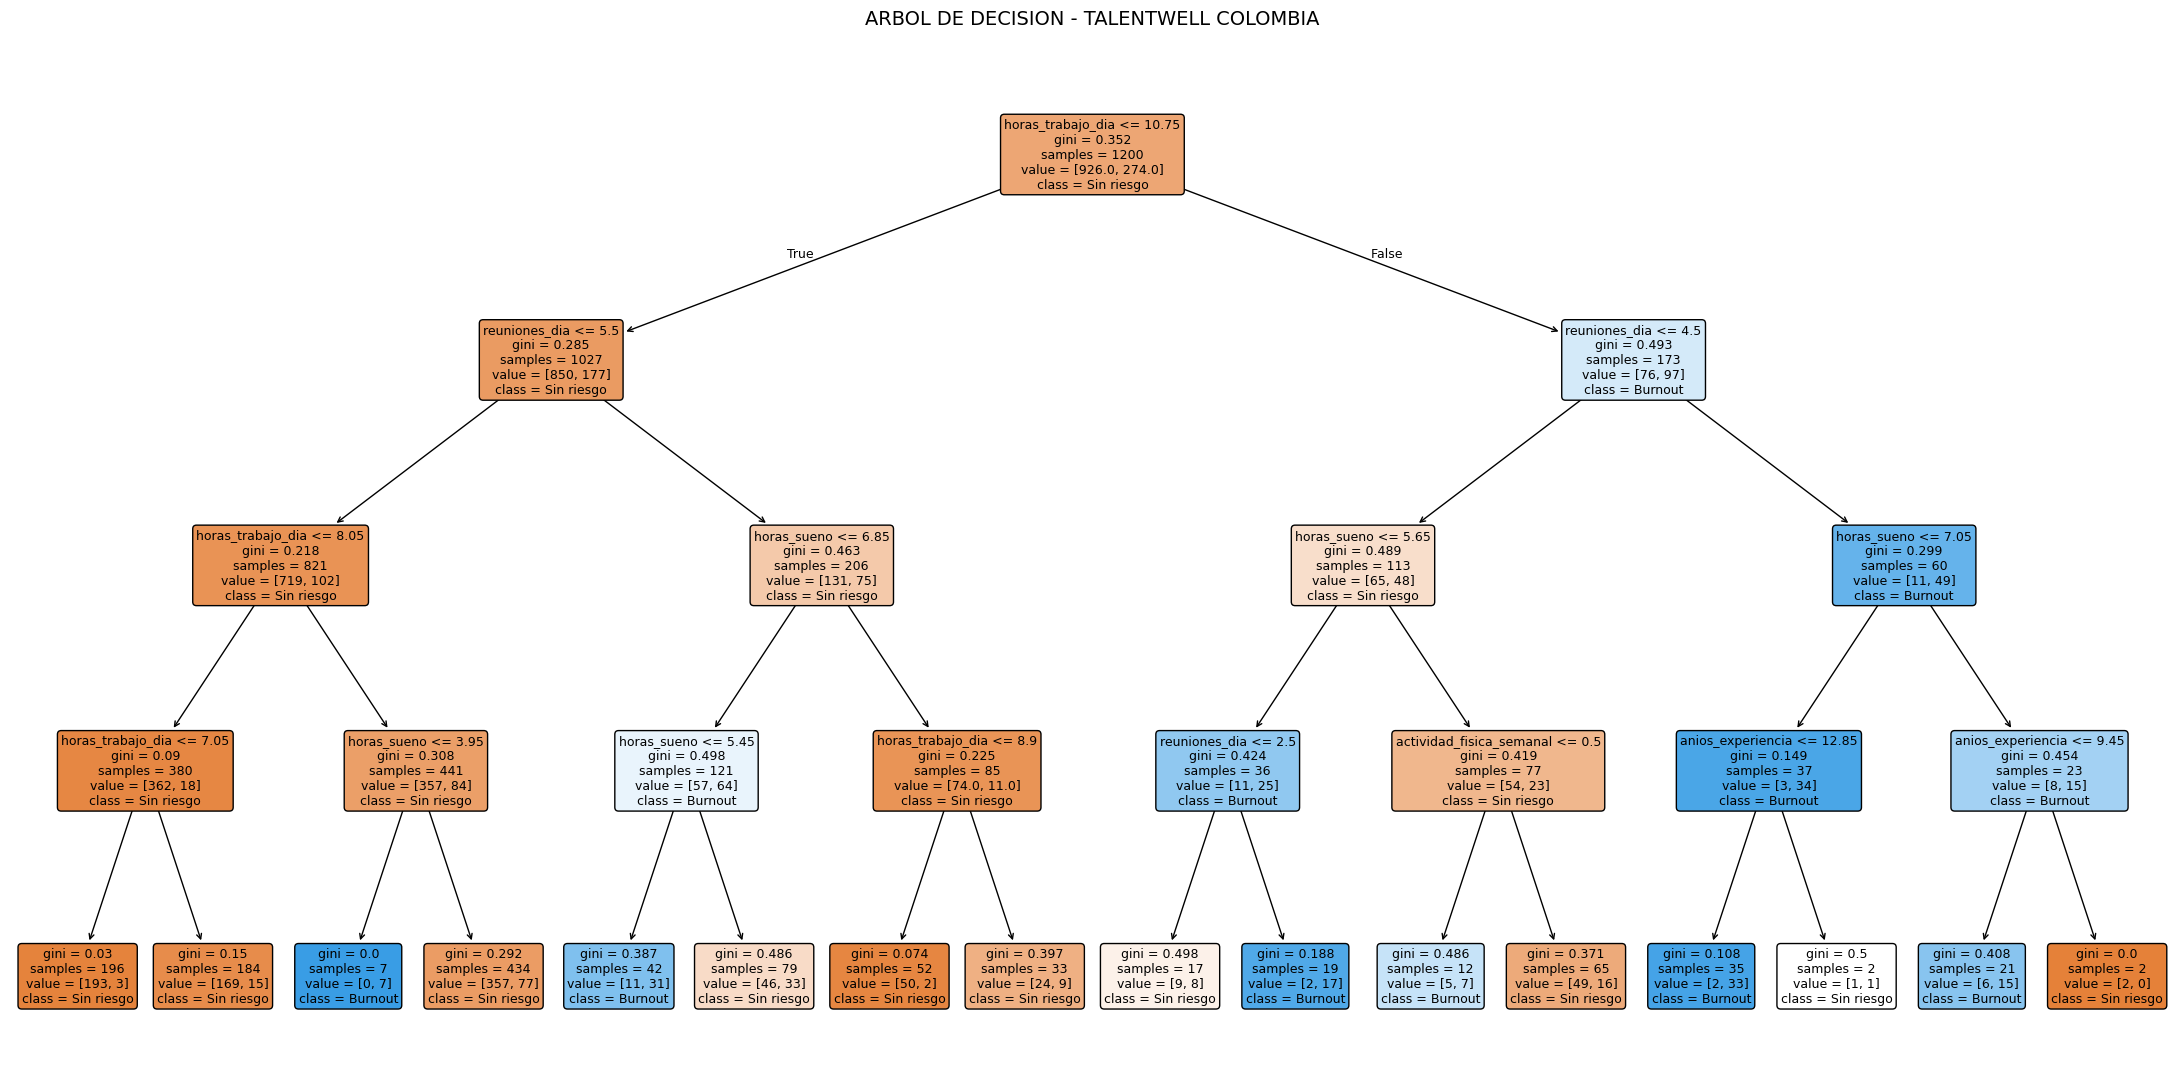

In [12]:
plt.figure(figsize=(22, 11))


plot_tree(
    arbol,
    feature_names=features,
    class_names=['Sin riesgo', 'Burnout'],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title(
    'ARBOL DE DECISION - TALENTWELL COLOMBIA',
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.show()

## Metricas de evaluación

In [13]:
#La accuracy = porcentaje de aciertos totales del modelo.
#Accuracy es engañosa cuando las clases están desbalanceadas

#Precision = De los que predije burnout, ¿Cuantos relamente lo tienen?
#Recall = De todos los burnout reales, ¿cuantos detecté?
#F1-score = Media entre precision y recall.

#VP = predije burnout, era bornout.
#VN = predije sin riesgo, era sin riesgo.
#FP = Falso positivo. Predije burnout, pero no lo era.
#FN = Falso negativo. predije sin riesgo, pero si tenía burnout (es el más peligroso).


y_pred_arbol = arbol.predict(X_test)

acc_arbol = accuracy_score(y_test, y_pred_arbol)

baseline = (y_test == 0).mean()

print(f"Accuracy del arbol: {acc_arbol:.1%}")
print(f"Accuracy modelo estúpido: {baseline:1%} (predice simepre 0)")
print(f"Ganancia sobre baseline: {(acc_arbol - baseline)*100:.1f} puntos porcentuales")
print()

print("=" * 50)
print("Reporte Completo por clase")
print("=" * 50)

print(classification_report(y_test, y_pred_arbol, target_names=['Sin Riesgo', 'Burnout']))


Accuracy del arbol: 81.3%
Accuracy modelo estúpido: 77.000000% (predice simepre 0)
Ganancia sobre baseline: 4.3 puntos porcentuales

Reporte Completo por clase
              precision    recall  f1-score   support

  Sin Riesgo       0.83      0.95      0.89       231
     Burnout       0.69      0.35      0.46        69

    accuracy                           0.81       300
   macro avg       0.76      0.65      0.67       300
weighted avg       0.80      0.81      0.79       300

